## Data Layer Comparison

Compares token efficiency against three external data layers:
- Population density (GHS Population Grid 2025)
- Internet penetration (World Bank 2022)
- Carbon intensity of electricity (Our World in Data 2022)

Requires statistical_analysis.py to have been run first,
as it depends on dfq with country assignments.

Input:  ResultsWithAllThreeRatios.json
        GHS_POP_E2025_GLOBE_R2023A_54009_1000_V1_0.tif
Output: env_cost_gpt4o.png / .pdf
        env_cost_deepseek.png / .pdf
        env_cost_mistral.png / .pdf
        token_efficiency_by_script.png

Cells after quality filter: 6,911
Country assigned to 5951 cells

── Population density analysis ──
  Running zonal statistics (this may take a few minutes)...
  Valid pop_mean: 6909 / 6911

  Spearman correlation: token efficiency vs population sum (log)
    GPT-4o: r = -0.222, p = 0.000000
    DeepSeek-LLM-7B: r = -0.186, p = 0.000000
    Mistral-7B: r = -0.247, p = 0.000000

  Population-weighted mean token ratio:
    GPT-4o: unweighted = 0.412, weighted = 0.374
    DeepSeek-LLM-7B: unweighted = 0.333, weighted = 0.311
    Mistral-7B: unweighted = 0.310, weighted = 0.280

── Internet penetration analysis ──
  Cells matched: 5500

  Spearman correlation: token efficiency vs internet penetration
    GPT-4o: r = 0.262, p = 0.000000
    DeepSeek-LLM-7B: r = 0.203, p = 0.000000
    Mistral-7B: r = 0.274, p = 0.000000

── Writing system detection ──
  Detecting dominant script per cell...

  Script distribution (20+ cells only):
script_final
Latin — Basic         4892
Cyrillic            

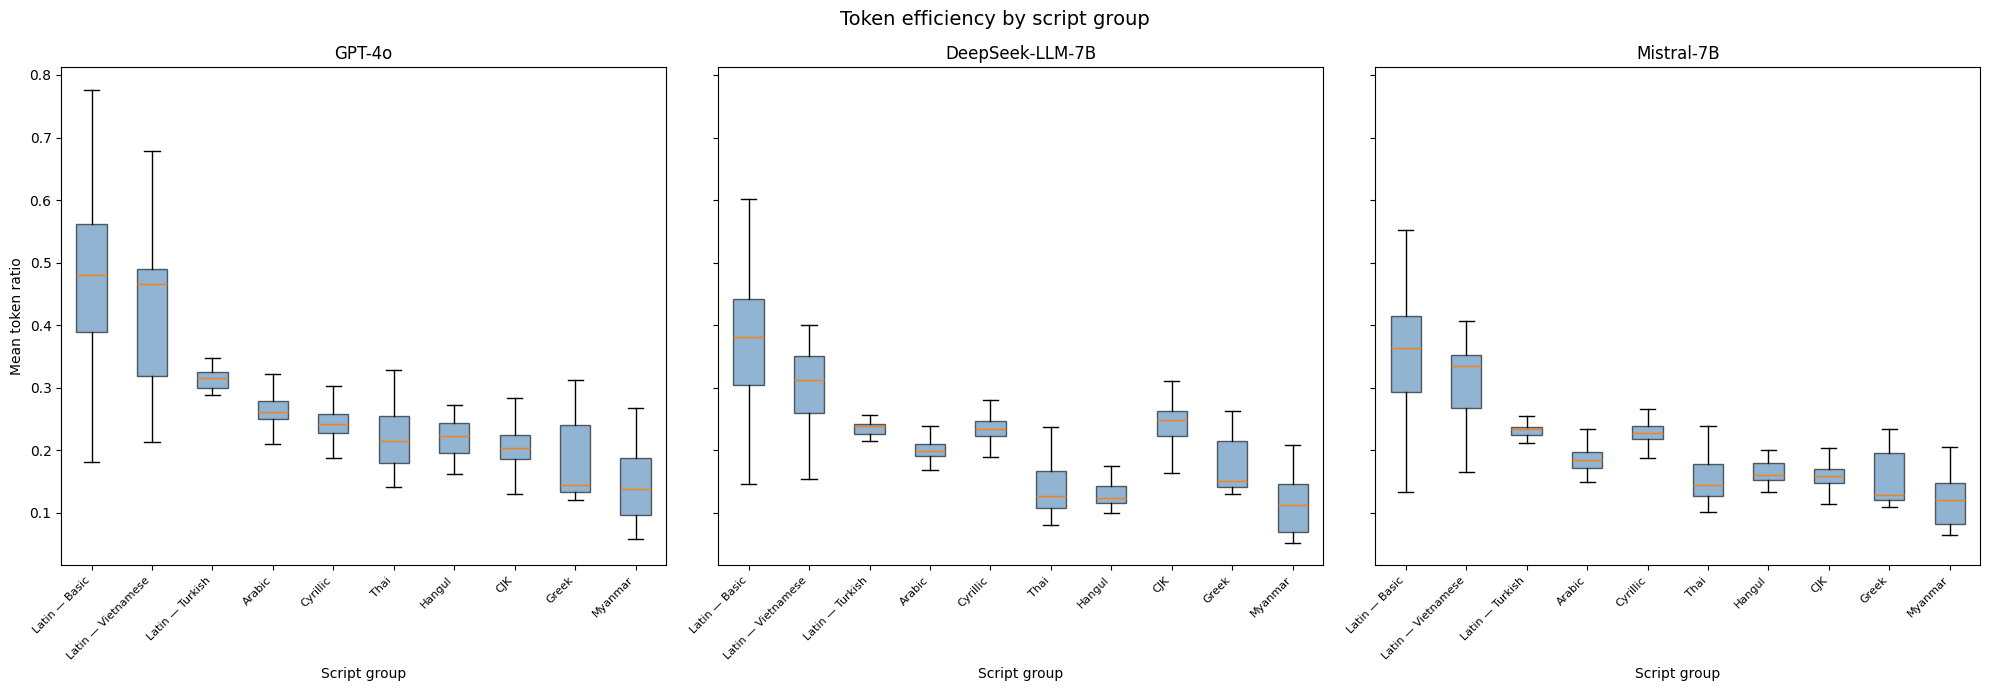

  Saved: token_efficiency_by_script.png

── Carbon intensity analysis ──
  Cells matched: 5812

  Spearman correlation: token efficiency vs CO2 intensity
    GPT-4o: r = -0.386, p = 0.000000
    DeepSeek-LLM-7B: r = -0.351, p = 0.000000
    Mistral-7B: r = -0.413, p = 0.000000

  Environmental cost index descriptive statistics:
       env_cost_chatgpt  env_cost_deepseek  env_cost_mistral
count           5812.00            5812.00           5812.00
mean            1304.05            1511.20           1678.46
std              993.59            1092.76           1235.63
min               43.26              53.95             56.84
25%              580.42             751.63            803.94
50%             1006.63            1266.87           1336.09
75%             1864.90            2139.08           2290.12
max             9557.12           10442.04           8172.03

── Generating environmental cost maps ──
  Building map for env_cost_chatgpt...


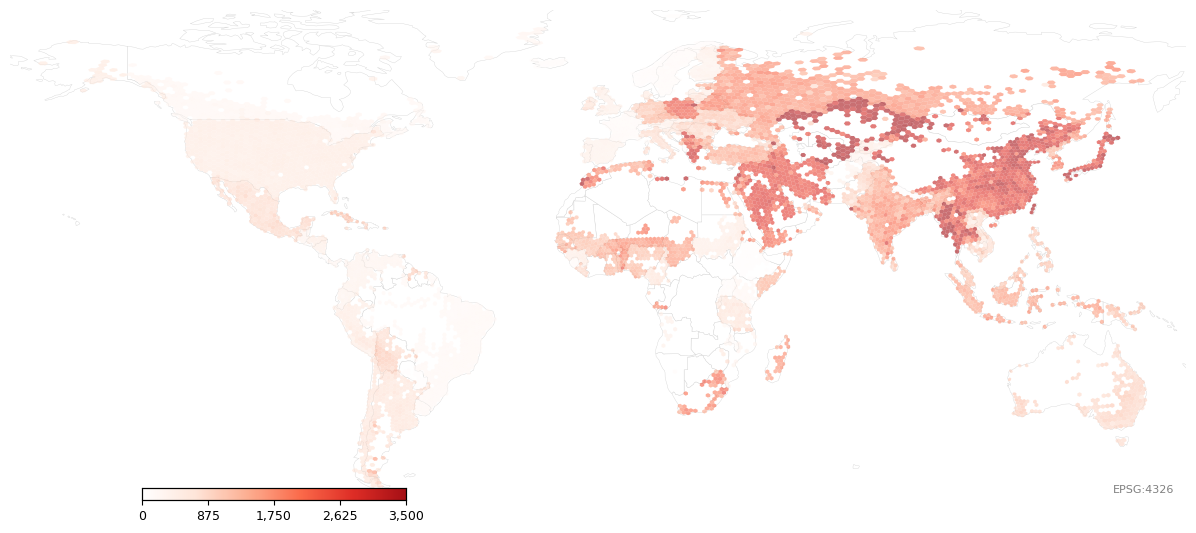

  Saved: MAPS/env_cost_gpt4o.png and MAPS/env_cost_gpt4o.pdf
  Building map for env_cost_deepseek...


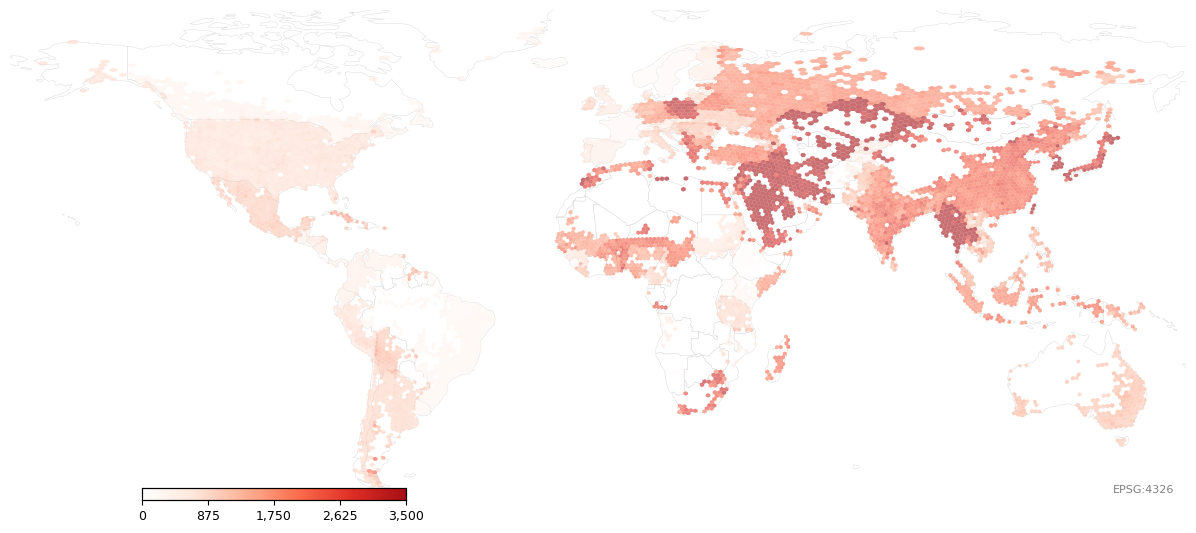

  Saved: MAPS/env_cost_deepseek.png and MAPS/env_cost_deepseek.pdf
  Building map for env_cost_mistral...


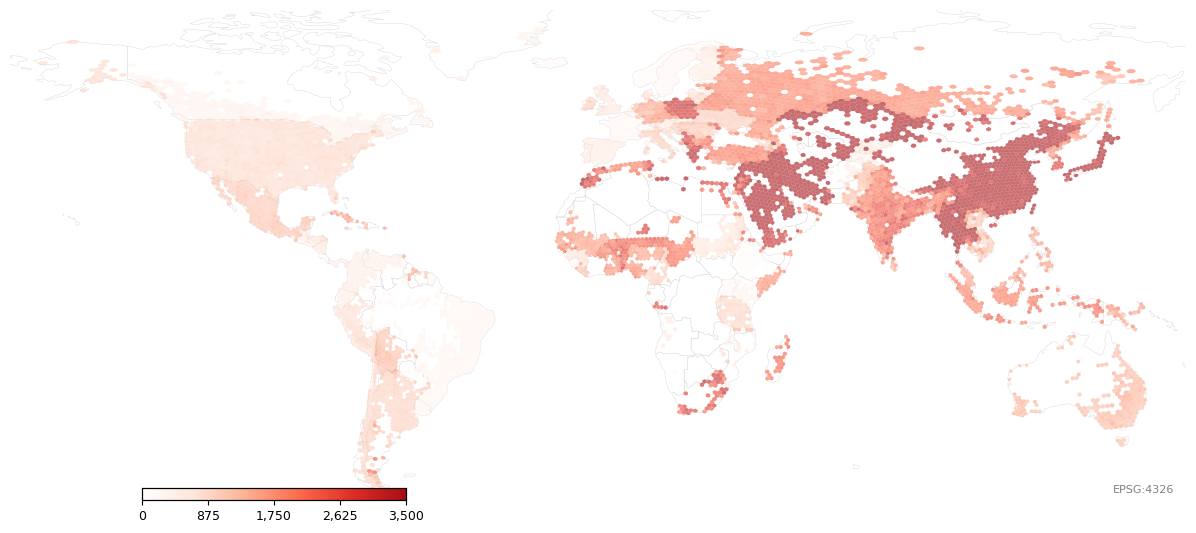

  Saved: MAPS/env_cost_mistral.png and MAPS/env_cost_mistral.pdf

All analyses complete.


In [1]:


# ── 1. IMPORTS ────────────────────────────────────────────────────────────────
import json
import os
import math
import unicodedata
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import h3
from pathlib import Path
from collections import Counter
from shapely.geometry import Polygon
from pyproj import Transformer
from rasterstats import zonal_stats
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

# ── 2. CONFIGURATION ──────────────────────────────────────────────────────────
DATA_PATH    = "ResultsWithAllThreeRatios.json"
RASTER_PATH  = "GHS_POP_E2025_GLOBE_R2023A_54009_1000_V1_0.tif"
MIN_NAMES    = 100
MIN_SCRIPT_CELLS = 20
WEST, SOUTH, EAST, NORTH = -175, -60, 165, 80

os.makedirs("MAPS", exist_ok=True)

# ── 3. LOAD AND PREPARE DATA ──────────────────────────────────────────────────
assert Path(DATA_PATH).exists(), f"{DATA_PATH} not found."

with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

def _get(d, k, default=None):
    return d.get(k, default) if isinstance(d, dict) else default

rows = []
for cell, obj in raw.items():
    entries = _get(obj, "entries", None)
    num_names = len(entries) if isinstance(entries, list) else 0
    chat = _get(obj, "chatgpt_avg_token_ratio")
    deep = _get(obj, "deepseek_avg_token_ratio")
    mist = _get(obj, "mistral_avg_token_ratio")
    lat, lon = h3.h3_to_geo(cell)
    rows.append({
        "h3_cell":      cell,
        "centroid_lat": lat,
        "centroid_lon": lon,
        "num_names":    num_names,
        "chatgpt_avg":  chat,
        "deepseek_avg": deep,
        "mistral_avg":  mist,
        "entries":      entries
    })

df_all = pd.DataFrame(rows)
for c in ["num_names", "chatgpt_avg", "deepseek_avg", "mistral_avg"]:
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

dfq = df_all[df_all["num_names"] >= MIN_NAMES].copy()
print(f"Cells after quality filter: {len(dfq):,}")

# ── 4. COUNTRY ASSIGNMENT ─────────────────────────────────────────────────────
world_countries = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
).to_crs("EPSG:4326")[["NAME", "geometry"]].rename(columns={"NAME": "country"})

gdf_points = gpd.GeoDataFrame(
    dfq,
    geometry=gpd.points_from_xy(dfq["centroid_lon"], dfq["centroid_lat"]),
    crs="EPSG:4326"
)

dfq = gpd.sjoin(
    gdf_points, world_countries,
    how="left", predicate="within"
).drop(columns=["index_right", "geometry"])

print(f"Country assigned to {dfq['country'].notna().sum()} cells")

# ── 5. HELPER FUNCTIONS ───────────────────────────────────────────────────────
def spearman_from_series(a, b):
    ra = pd.Series(a).rank(method="average")
    rb = pd.Series(b).rank(method="average")
    return ra.corr(rb)

def fetch_world_bank(url):
    r = requests.get(url)
    data = r.json()[1]
    records = []
    for entry in data:
        if entry["value"] is not None:
            records.append({
                "country": entry["country"]["value"],
                "value":   entry["value"]
            })
    return pd.DataFrame(records)

# ── 6. POPULATION DENSITY (GHS RASTER) ───────────────────────────────────────
print("\n── Population density analysis ──")

assert Path(RASTER_PATH).exists(), f"{RASTER_PATH} not found."

def build_h3_polygons(dataframe):
    polys = [Polygon(h3.h3_to_geo_boundary(c, geo_json=True))
             for c in dataframe["h3_cell"]]
    return gpd.GeoDataFrame(dataframe.copy(), geometry=polys, crs="EPSG:4326")

gdf = build_h3_polygons(dfq)
gdf_proj = gdf.to_crs("ESRI:54009")

print("  Running zonal statistics (this may take a few minutes)...")
zs = zonal_stats(gdf_proj, RASTER_PATH,
                 stats=["mean", "sum"], nodata=-200.0, all_touched=False)
gdf["pop_mean"] = [s["mean"] for s in zs]
gdf["pop_sum"]  = [s["sum"]  for s in zs]

print(f"  Valid pop_mean: {gdf['pop_mean'].notna().sum()} / {len(gdf)}")

pop_corr = gdf.drop_duplicates(subset="h3_cell").dropna(
    subset=["pop_mean", "pop_sum", "chatgpt_avg", "deepseek_avg", "mistral_avg"]
).copy()
pop_corr["pop_sum_log"]  = np.log1p(pop_corr["pop_sum"])
pop_corr["pop_mean_log"] = np.log1p(pop_corr["pop_mean"])

print("\n  Spearman correlation: token efficiency vs population sum (log)")
for model, col in [("GPT-4o", "chatgpt_avg"),
                   ("DeepSeek-LLM-7B", "deepseek_avg"),
                   ("Mistral-7B", "mistral_avg")]:
    r, p = stats.spearmanr(pop_corr[col], pop_corr["pop_sum_log"])
    print(f"    {model}: r = {r:.3f}, p = {p:.6f}")

# population weighted mean
print("\n  Population-weighted mean token ratio:")
for model, col in [("GPT-4o", "chatgpt_avg"),
                   ("DeepSeek-LLM-7B", "deepseek_avg"),
                   ("Mistral-7B", "mistral_avg")]:
    unweighted = pop_corr[col].mean()
    weighted   = np.average(pop_corr[col], weights=pop_corr["pop_sum"])
    print(f"    {model}: unweighted = {unweighted:.3f}, weighted = {weighted:.3f}")

# ── 7. INTERNET PENETRATION (WORLD BANK) ─────────────────────────────────────
print("\n── Internet penetration analysis ──")

net_url = "https://api.worldbank.org/v2/country/all/indicator/IT.NET.USER.ZS?date=2022&format=json&per_page=300"
net_df  = fetch_world_bank(net_url).rename(columns={"value": "internet_pct"})

internet_name_map = {
    "Czech Republic": "Czechia",
    "Democratic Republic of the Congo": "Congo, Dem. Rep.",
    "Ivory Coast": "Cote d'Ivoire",
    "People's Republic of China": "China",
    "Republic of the Congo": "Congo, Rep.",
    "Somaliland": None,
    "The Bahamas": "Bahamas, The",
    "The Gambia": "Gambia, The",
    "Turkish Republic of Northern Cyprus": None,
    "United States of America": "United States",
    "Venezuela": "Venezuela, RB",
    "Russia": "Russian Federation",
    "Iran": "Iran, Islamic Rep.",
    "Syria": "Syrian Arab Republic",
    "Turkey": "Turkiye",
    "Vietnam": "Viet Nam",
    "Egypt": "Egypt, Arab Rep.",
    "South Korea": "Korea, Rep.",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Laos": "Lao PDR",
    "Slovakia": "Slovak Republic",
    "Yemen": "Yemen, Rep.",
    "Western Sahara": None,
    "North Korea": None,
    "Taiwan": None,
}

dfq["country_wb"] = dfq["country"].map(lambda x: internet_name_map.get(x, x))
inet_merged = dfq.drop_duplicates(subset="h3_cell").copy()
inet_merged = inet_merged[inet_merged["country_wb"].notna()]
inet_merged = inet_merged.dropna(subset=["chatgpt_avg", "deepseek_avg", "mistral_avg"])
inet_merged = inet_merged.merge(
    net_df.rename(columns={"country": "country_wb"}),
    on="country_wb", how="inner"
)
print(f"  Cells matched: {len(inet_merged)}")

print("\n  Spearman correlation: token efficiency vs internet penetration")
for model, col in [("GPT-4o", "chatgpt_avg"),
                   ("DeepSeek-LLM-7B", "deepseek_avg"),
                   ("Mistral-7B", "mistral_avg")]:
    r, p = stats.spearmanr(inet_merged[col], inet_merged["internet_pct"])
    print(f"    {model}: r = {r:.3f}, p = {p:.6f}")

# ── 8. WRITING SYSTEM DETECTION ───────────────────────────────────────────────
print("\n── Writing system detection ──")

def detect_script(text):
    scripts = []
    for char in text:
        if char.isspace() or not char.isalpha():
            continue
        try:
            name = unicodedata.name(char, "")
            if "CJK" in name or "HIRAGANA" in name or "KATAKANA" in name:
                scripts.append("CJK")
            elif "HANGUL"    in name: scripts.append("Hangul")
            elif "ARABIC"    in name: scripts.append("Arabic")
            elif "CYRILLIC"  in name: scripts.append("Cyrillic")
            elif "GREEK"     in name: scripts.append("Greek")
            elif "HEBREW"    in name: scripts.append("Hebrew")
            elif "THAI"      in name: scripts.append("Thai")
            elif "MYANMAR"   in name: scripts.append("Myanmar")
            elif "GEORGIAN"  in name: scripts.append("Georgian")
            elif "ARMENIAN"  in name: scripts.append("Armenian")
            elif "DEVANAGARI" in name: scripts.append("Devanagari")
            elif "LATIN"     in name: scripts.append("Latin")
            else:                     scripts.append("Other")
        except Exception:
            scripts.append("Other")
    return Counter(scripts).most_common(1)[0][0] if scripts else "Unknown"

def detect_latin_subtype(text):
    vietnamese_chars = set("ắằẳẵặấầẩẫậáàảãạéèẻẽẹíìỉĩịóòỏõọúùủũụýỳỷỹỵđơưếềểễệố")
    turkish_chars    = set("ğşıİĞŞ")
    text_chars = set(text)
    if text_chars & vietnamese_chars: return "Latin — Vietnamese"
    if text_chars & turkish_chars:    return "Latin — Turkish"
    return "Latin — Basic"

def dominant_script_for_cell(entries):
    all_scripts   = []
    latin_subtypes = []
    for entry in entries:
        name = entry.get("name", "")
        if not name:
            continue
        script = detect_script(name)
        all_scripts.append(script)
        if script == "Latin":
            latin_subtypes.append(detect_latin_subtype(name))
    if not all_scripts:
        return "Unknown"
    dominant = Counter(all_scripts).most_common(1)[0][0]
    if dominant == "Latin" and latin_subtypes:
        return Counter(latin_subtypes).most_common(1)[0][0]
    return dominant

print("  Detecting dominant script per cell...")
cell_scripts = {}
for cell, obj in raw.items():
    entries = obj.get("entries", [])
    if isinstance(entries, list) and entries:
        cell_scripts[cell] = dominant_script_for_cell(entries)
    else:
        cell_scripts[cell] = "Unknown"

dfq["script_final"] = dfq["h3_cell"].map(cell_scripts)

script_clean = dfq[dfq["num_names"] >= MIN_NAMES].drop_duplicates(subset="h3_cell").copy()
script_clean = script_clean.dropna(subset=["chatgpt_avg", "deepseek_avg", "mistral_avg"])

valid_scripts = script_clean["script_final"].value_counts()
valid_scripts = valid_scripts[valid_scripts >= MIN_SCRIPT_CELLS].index.tolist()
script_clean  = script_clean[script_clean["script_final"].isin(valid_scripts)]

print(f"\n  Script distribution ({MIN_SCRIPT_CELLS}+ cells only):")
print(script_clean["script_final"].value_counts().to_string())

print("\n  Mean token efficiency per script group:")
detail_means = script_clean.groupby("script_final")[
    ["chatgpt_avg", "deepseek_avg", "mistral_avg"]
].mean().round(3).sort_values("chatgpt_avg", ascending=False)
print(detail_means.to_string())

print("\n  Kruskal-Wallis test across script groups:")
for model, col in [("GPT-4o", "chatgpt_avg"),
                   ("DeepSeek-LLM-7B", "deepseek_avg"),
                   ("Mistral-7B", "mistral_avg")]:
    groups = [script_clean[script_clean["script_final"] == s][col].dropna().values
              for s in valid_scripts]
    h_stat, p = stats.kruskal(*groups)
    print(f"    {model}: H = {h_stat:.3f}, p = {p:.6f}")

# script box plots
script_order = detail_means.index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
for ax, (model, col) in zip(axes, [("GPT-4o", "chatgpt_avg"),
                                    ("DeepSeek-LLM-7B", "deepseek_avg"),
                                    ("Mistral-7B", "mistral_avg")]):
    groups = [script_clean[script_clean["script_final"] == s][col].dropna().values
              for s in script_order]
    bp = ax.boxplot(groups, patch_artist=True, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor("steelblue")
        patch.set_alpha(0.6)
    ax.set_xticklabels(script_order, rotation=45, ha="right", fontsize=8)
    ax.set_title(model, fontsize=12)
    ax.set_xlabel("Script group", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("Mean token ratio", fontsize=10)
fig.suptitle("Token efficiency by script group", fontsize=14)
plt.tight_layout()
plt.savefig("token_efficiency_by_script.png", dpi=300, bbox_inches="tight")
plt.show()
print("  Saved: token_efficiency_by_script.png")

# ── 9. CARBON INTENSITY (OUR WORLD IN DATA) ───────────────────────────────────
print("\n── Carbon intensity analysis ──")

carbon_url = "https://ourworldindata.org/grapher/carbon-intensity-electricity.csv?v=1&csvType=full&useColumnShortNames=true"
response   = requests.get(carbon_url)
carbon_raw_df = pd.read_csv(carbon_url)

carbon_2022 = carbon_raw_df[carbon_raw_df["year"] == 2022].copy()
carbon_2022 = carbon_2022.dropna(subset=["code"])
carbon_2022 = carbon_2022.rename(columns={
    "entity": "country_owid",
    "co2_intensity__gco2_kwh": "co2_intensity"
})

carbon_name_map = {
    "Czech Republic":                    "Czechia",
    "Democratic Republic of the Congo":  "Democratic Republic of Congo",
    "Ivory Coast":                       "Cote d'Ivoire",
    "People's Republic of China":        "China",
    "Republic of the Congo":             "Congo",
    "Somaliland":                        None,
    "The Bahamas":                       "Bahamas",
    "The Gambia":                        "Gambia",
    "Turkish Republic of Northern Cyprus": None,
    "United States of America":          "United States",
    "Western Sahara":                    None,
}

dfq["country_carbon"] = dfq["country"].map(lambda x: carbon_name_map.get(x, x))

carbon_merged_df = dfq.drop_duplicates(subset="h3_cell").copy()
carbon_merged_df = carbon_merged_df.dropna(
    subset=["country_carbon", "chatgpt_avg", "deepseek_avg", "mistral_avg"]
)
carbon_merged_df = carbon_merged_df[carbon_merged_df["country_carbon"].notna()]
carbon_merged_df = carbon_merged_df.merge(
    carbon_2022[["country_owid", "co2_intensity"]].rename(
        columns={"country_owid": "country_carbon"}
    ),
    on="country_carbon", how="inner"
)
print(f"  Cells matched: {len(carbon_merged_df)}")

carbon_merged_df["env_cost_chatgpt"]  = (1 / carbon_merged_df["chatgpt_avg"])  * carbon_merged_df["co2_intensity"]
carbon_merged_df["env_cost_deepseek"] = (1 / carbon_merged_df["deepseek_avg"]) * carbon_merged_df["co2_intensity"]
carbon_merged_df["env_cost_mistral"]  = (1 / carbon_merged_df["mistral_avg"])  * carbon_merged_df["co2_intensity"]

print("\n  Spearman correlation: token efficiency vs CO2 intensity")
for model, col in [("GPT-4o", "chatgpt_avg"),
                   ("DeepSeek-LLM-7B", "deepseek_avg"),
                   ("Mistral-7B", "mistral_avg")]:
    r, p = stats.spearmanr(carbon_merged_df[col], carbon_merged_df["co2_intensity"])
    print(f"    {model}: r = {r:.3f}, p = {p:.6f}")

print("\n  Environmental cost index descriptive statistics:")
print(carbon_merged_df[["env_cost_chatgpt",
                         "env_cost_deepseek",
                         "env_cost_mistral"]].describe().round(2))

# ── 10. ENVIRONMENTAL COST MAPS ───────────────────────────────────────────────
print("\n── Generating environmental cost maps ──")

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
).to_crs("EPSG:4326")
world = world[world["CONTINENT"] != "Antarctica"]

cmap_env = LinearSegmentedColormap.from_list(
    "white_to_red",
    ["#ffffff", "#fee5d9", "#fcae91", "#fb6a4a", "#de2d26", "#a50f15"]
)
norm_env = Normalize(vmin=0, vmax=3500)

def make_env_cost_gdf(cost_col):
    rows = []
    for _, row in carbon_merged_df.iterrows():
        v = row[cost_col]
        if not isinstance(v, (int, float)) or math.isnan(v):
            continue
        rows.append((row["h3_cell"], float(v)))
    df_map = pd.DataFrame(rows, columns=["cell", "env_cost"])
    polys  = [Polygon(h3.h3_to_geo_boundary(c, geo_json=True))
              for c in df_map["cell"]]
    return gpd.GeoDataFrame(df_map, geometry=polys, crs="EPSG:4326")

def plot_env_map(gdf_plot, out_png, out_pdf):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_facecolor("#d7dedf")
    world.plot(ax=ax, color="white", edgecolor="#cfcfcf",
               linewidth=0.25, zorder=1)
    gdf_plot.plot(ax=ax, column="env_cost", cmap=cmap_env, norm=norm_env,
                  alpha=0.60, linewidth=0.0, edgecolor="none",
                  antialiased=True, rasterized=True, zorder=2)
    ax.set_axis_off()
    ax.set_xlim(WEST, EAST)
    ax.set_ylim(SOUTH, NORTH)
    sm  = ScalarMappable(norm=norm_env, cmap=cmap_env)
    sm.set_array([])
    cax = fig.add_axes([0.12, 0.11, 0.22, 0.02])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_ticks([0, 875, 1750, 2625, 3500])
    cbar.set_ticklabels(["0", "875", "1,750", "2,625", "3,500"])
    cbar.ax.tick_params(labelsize=9)
    for spine in cax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("black")
    cax.set_facecolor("white")
    ax.text(0.99, 0.02, "EPSG:4326", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=8, color="grey")
    fig.subplots_adjust(left=0.01, right=0.99, top=0.98, bottom=0.05)
    fig.savefig(out_png, dpi=500, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {out_png} and {out_pdf}")

out_maps = {
    "env_cost_chatgpt":  ("MAPS/env_cost_gpt4o.png",    "MAPS/env_cost_gpt4o.pdf"),
    "env_cost_deepseek": ("MAPS/env_cost_deepseek.png",  "MAPS/env_cost_deepseek.pdf"),
    "env_cost_mistral":  ("MAPS/env_cost_mistral.png",   "MAPS/env_cost_mistral.pdf"),
}
for cost_col, (out_png, out_pdf) in out_maps.items():
    print(f"  Building map for {cost_col}...")
    gdf_env = make_env_cost_gdf(cost_col)
    plot_env_map(gdf_env, out_png, out_pdf)

print("\nAll analyses complete.")